In [1]:
import os
os.chdir(os.path.join(os.path.dirname("__file__"), "../.."))

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import matplotlib.pyplot as plt
import tqdm

from transformers import AutoTokenizer

/Users/samswitz/miniforge3/envs/sae/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
EXPANSION = 4

In [9]:
metrics = pd.read_csv(f"training_metrics/training_metrics_{EXPANSION}x.csv")

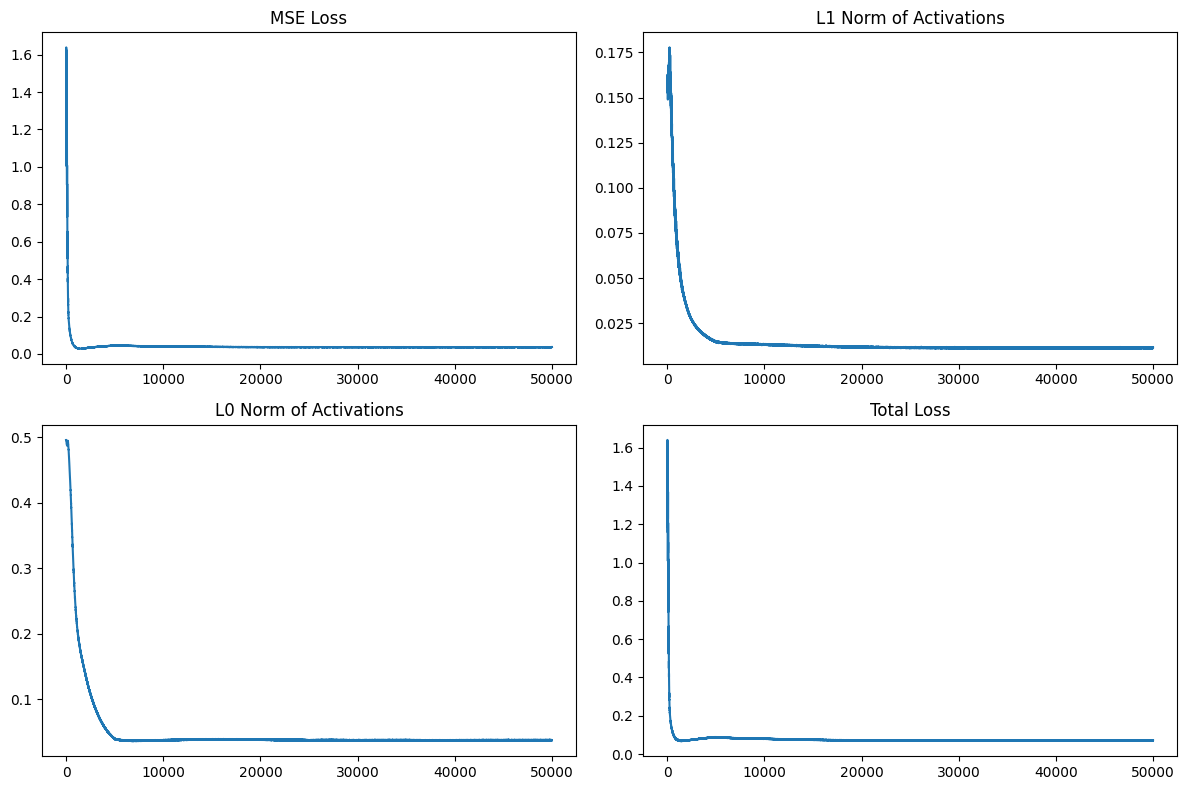

In [10]:
# plot the metrics
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(metrics['mse'])
plt.title('MSE Loss')
plt.subplot(2, 2, 2)
plt.plot(metrics['l1'])
plt.title('L1 Norm of Activations')
plt.subplot(2, 2, 3)
plt.plot(metrics['l0'])
plt.title('L0 Norm of Activations')
plt.subplot(2, 2, 4)
plt.plot(metrics['loss'])
plt.title('Total Loss')
plt.tight_layout()
plt.show()

In [11]:
from sae import SparseAutoEncoder
from datasets import load_dataset

# Load tokenizer only (no need for the full model)
tokenizer = AutoTokenizer.from_pretrained("EleutherAI/pythia-70m")

MODEL_PATH = f"saved_models/sae_model_{EXPANSION}x.pt"

# Load saved SAE
d = 512
m = d * EXPANSION
sae = SparseAutoEncoder(d=d, m=m)
sae.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
sae.eval()

# Load activations and process through SAE encoder in batches
# Full encoder output would be ~88GB, so we process in chunks
NUM_TEXTS = 50000
ACTIVATIONS_PATH = f"activations/activations_{NUM_TEXTS}.pt"

activations = torch.load(ACTIVATIONS_PATH, map_location="cpu")
n_tokens = activations.shape[0]
BATCH_SIZE = 4096

# We only need top-k per feature, so we track running top-k instead of storing everything
K = 20  # track top-K activating tokens per feature
top_vals = torch.zeros(m, K)
top_idxs = torch.full((m, K), -1, dtype=torch.long)

with torch.no_grad():
    for start in tqdm.trange(0, n_tokens, BATCH_SIZE):
        batch = activations[start:start + BATCH_SIZE]
        feat_acts = sae.encoder(batch)  # (batch, m)

        for j in range(feat_acts.shape[1]):
            combined_vals = torch.cat([top_vals[j], feat_acts[:, j]])
            combined_idxs = torch.cat([top_idxs[j], torch.arange(start, start + feat_acts.shape[0])])
            best = combined_vals.topk(K)
            top_vals[j] = best.values
            top_idxs[j] = combined_idxs[best.indices]

del activations

# Re-tokenize the same texts to get token strings
# TransformerLens prepends a BOS token per text, so we must do the same
dataset = load_dataset("openwebtext", split="train", streaming=True)
BOS = tokenizer.bos_token_id

all_tokens = []
all_contexts = []
for i, example in enumerate(tqdm.tqdm(dataset, total=NUM_TEXTS)):
    if i >= NUM_TEXTS:
        break
    text = example["text"][:512]
    token_ids = [BOS] + tokenizer.encode(text, add_special_tokens=False)
    tokens = [tokenizer.decode(tid) for tid in token_ids]
    for t in tokens:
        all_tokens.append(t)
        all_contexts.append(text)

print(f"Total tokens: {len(all_tokens)}, activations: {n_tokens}")
assert len(all_tokens) == n_tokens, f"Mismatch! tokens={len(all_tokens)} vs activations={n_tokens}"
print(f"Tracked top-{K} activations for {m} features")

100%|██████████| 50000/50000 [00:29<00:00, 1719.75it/s]

Total tokens: 5884867, activations: 5884867
Tracked top-20 activations for 2048 features


In [27]:
def inspect_feature(feature_idx, k=10):
    k = min(k, K)
    vals = top_vals[feature_idx, :k]
    idxs = top_idxs[feature_idx, :k]

    print(f"Feature {feature_idx} — top {k} activating tokens:\n")
    for val, idx in zip(vals, idxs):
        idx = idx.item()
        if idx < 0:
            break
        token = all_tokens[idx]
        context = all_contexts[idx]
        print(f"  {val:.3f}  token={repr(token):>15s}   context: {context[:80]}")

# try a few features
inspect_feature(1660)

Feature 1660 — top 10 activating tokens:

  0.001  token=  ' commercial'   context: Pirelli motorsport boss Paul Hembery is set to present F1 commercial supremo Ber


In [26]:
# Features where the best activation is 0 are dead
alive_mask = top_vals[:, 0] > 0
dead_count = (~alive_mask).sum().item()

# Sort alive features by their top activation (lowest = sparsest)
alive_idxs = torch.where(alive_mask)[0]
sorted_order = top_vals[alive_idxs, 0].argsort()
sparsest_idxs = alive_idxs[sorted_order]
# sparsest_idxs = torch.tensor([1896])

print(f"Dead features: {dead_count} / {m}")
print()
for idx in sparsest_idxs[:10]:
    idx = idx.item()
    # Count non-zero entries in top-K as a proxy
    n_active = (top_vals[idx] > 0).sum().item()
    print(f"Feature {idx}: top activation = {top_vals[idx, 0]:.4f} ({n_active}/{K} top slots active)")
    inspect_feature(idx, k=5)
    print()

Dead features: 5 / 2048

Feature 1660: top activation = 0.0012 (1/20 top slots active)
Feature 1660 — top 5 activating tokens:

  0.001  token=  ' commercial'   context: Pirelli motorsport boss Paul Hembery is set to present F1 commercial supremo Ber

Feature 803: top activation = 0.0114 (1/20 top slots active)
Feature 803 — top 5 activating tokens:

  0.011  token=      ' manual'   context: Right-wing extremists communicating in confidential online chats in recent month

Feature 1727: top activation = 0.0260 (2/20 top slots active)
Feature 1727 — top 5 activating tokens:

  0.026  token=          ' Sc'   context: U.S. Border Patrol Scrutinized For Increasing Fatalities

Shooting deaths of for
  0.017  token=          ' is'   context: Incidentally, the new model sits on top of a revised range, where the twin-motor

Feature 772: top activation = 0.0420 (1/20 top slots active)
Feature 772 — top 5 activating tokens:

  0.042  token=    ' outreach'   context: The Man Up programme, which he

In [14]:
# Rank features by strongest top activation
best_per_feature = top_vals[:, 0]
ranked = best_per_feature.argsort(descending=True)

for rank, idx in enumerate(ranked[:20]):
    idx = idx.item()
    print(f"=== Rank {rank+1}: Feature {idx} (top activation: {best_per_feature[idx]:.3f}) ===")
    inspect_feature(idx, k=5)
    print()

=== Rank 1: Feature 1273 (top activation: 168.474) ===
Feature 1273 — top 5 activating tokens:

  168.474  token=            '.'   context: Δραματικά είναι τα στοιχεία για την κατάσταση στην αγορά εργασίας στην χώρας μας
  162.725  token=            '.'   context: Self-driving electric cars? Rad!! A Hyperloop train that can get you from New Yo
  162.225  token=            '.'   context: Fox News Channel pundits Greta Van Susteren and Erick Erickson have gone to war 
  161.964  token=            '.'   context: According to court documents, 29-year-old Markus Kaarma of Missoula, Mont. was i
  161.878  token=            '.'   context: Poison Ivy is a 1985 American made-for-television romantic comedy film starring 

=== Rank 2: Feature 1315 (top activation: 36.020) ===
Feature 1315 — top 5 activating tokens:

  36.020  token=            '.'   context: Δραματικά είναι τα στοιχεία για την κατάσταση στην αγορά εργασίας στην χώρας μας
  35.431  token=            '.'   context: Western Rite Ort

In [11]:
# Find the most "interpretable" features: ones where top-K tokens are consistent
# Score = fraction of top-K tokens that match the most common token
# Filter out single-char punctuation which dominates the max-activation ranking
from collections import Counter

BORING = {'.', "'", '-', '"', ',', '!', '?', ':', ';', '\n', ' ', ''}

scores = []
for feat_idx in range(m):
    idxs = top_idxs[feat_idx]
    valid = idxs[idxs >= 0]
    if len(valid) < 5:
        scores.append((feat_idx, 0.0, ""))
        continue
    tokens = [all_tokens[i.item()] for i in valid]
    counts = Counter(tokens)
    most_common_token, most_common_count = counts.most_common(1)[0]
    consistency = most_common_count / len(tokens)
    scores.append((feat_idx, consistency, most_common_token))

# Sort by consistency, filter out punctuation-only features
scores_filtered = [(idx, score, tok) for idx, score, tok in scores
                   if tok.strip() not in BORING and len(tok.strip()) > 0]
scores_filtered.sort(key=lambda x: -x[1])

print("Most consistent (interpretable) features:\n")
for feat_idx, consistency, top_token in scores_filtered[:30]:
    # if len(top_token) == 2:
    #     continue
    print(f"Feature {feat_idx}: {consistency:.0%} consistent, top token = {repr(top_token)}, max act = {top_vals[feat_idx, 0]:.3f}")
    inspect_feature(feat_idx, k=5)
    print()

Most consistent (interpretable) features:

Feature 2: 100% consistent, top token = ' keep', max act = 6.432
Feature 2 — top 5 activating tokens:

  6.432  token=        ' keep'   context: Have you ever asked yourself why it has been decades now since the Catholic chur
  6.421  token=        ' keep'   context: Not quite a Band of the Day, but just a heads up about a new act who is making w
  6.410  token=        ' keep'   context: On Nov. 1, 2007, the National Security Agency hosted a talk by Roger Dingledine,
  6.386  token=        ' keep'   context: I plowed through 14 bags of pasta in 31 days. Kathleen Elkins/Business Insider


  6.356  token=        ' keep'   context: When it comes to working on cycling skills, I always tell people the same thing.

Feature 4: 100% consistent, top token = ' case', max act = 4.726
Feature 4 — top 5 activating tokens:

  4.726  token=        ' case'   context: The complainant alleged that Owaisi's speech would "promote enmity between diffe
  4.618  tok

In [16]:
inspect_feature(2, k=5)
print()

Feature 2 — top 5 activating tokens:

  6.432  token=        ' keep'   context: Have you ever asked yourself why it has been decades now since the Catholic chur
  6.421  token=        ' keep'   context: Not quite a Band of the Day, but just a heads up about a new act who is making w
  6.410  token=        ' keep'   context: On Nov. 1, 2007, the National Security Agency hosted a talk by Roger Dingledine,
  6.386  token=        ' keep'   context: I plowed through 14 bags of pasta in 31 days. Kathleen Elkins/Business Insider


  6.356  token=        ' keep'   context: When it comes to working on cycling skills, I always tell people the same thing.



# W_dec Cosine Similarity Analysis

In [14]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Normalize decoder weights and compute pairwise cosine similarity
W_dec = sae.W_dec.data.clone()  # (m, d)
W_dec_normed = W_dec / W_dec.norm(dim=1, keepdim=True)
cos_sim = W_dec_normed @ W_dec_normed.T  # (m, m)

# Zero out the diagonal for analysis (self-similarity = 1 is uninteresting)
cos_sim_no_diag = cos_sim.clone()
cos_sim_no_diag.fill_diagonal_(0)

print(f"Decoder weight matrix: {W_dec.shape}")
print(f"Cosine similarity matrix: {cos_sim.shape}")
print(f"Max off-diagonal similarity: {cos_sim_no_diag.max():.4f}")
print(f"Mean off-diagonal similarity: {cos_sim_no_diag.sum() / (m * (m - 1)):.4f}")

Decoder weight matrix: torch.Size([2048, 512])
Cosine similarity matrix: torch.Size([2048, 2048])
Max off-diagonal similarity: 0.9012
Mean off-diagonal similarity: 0.0028


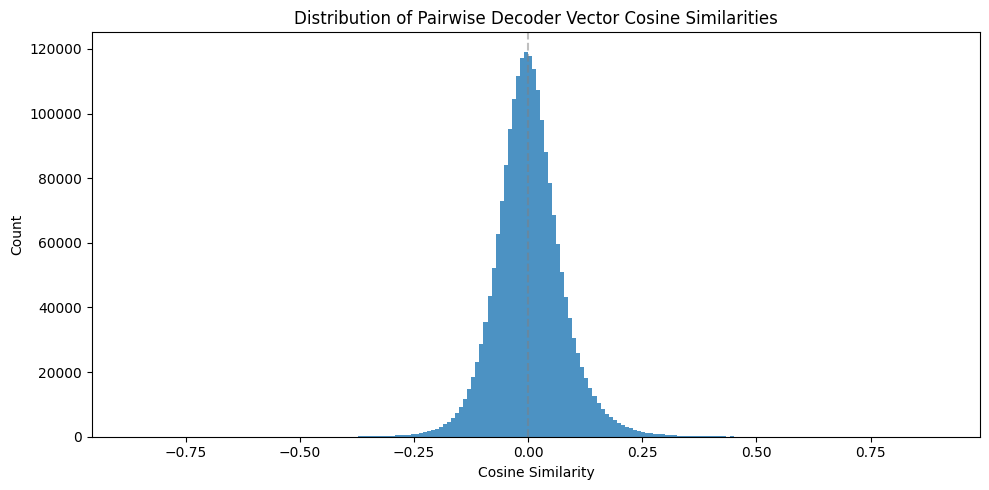

Pairs with |cos_sim| > 0.5: 331
Pairs with |cos_sim| > 0.7: 22
Pairs with |cos_sim| > 0.9: 1


In [15]:
# Histogram of pairwise cosine similarities (upper triangle only to avoid double-counting)
upper_tri = cos_sim[torch.triu(torch.ones(m, m, dtype=torch.bool), diagonal=1)].numpy()

plt.figure(figsize=(10, 5))
plt.hist(upper_tri, bins=200, edgecolor='none', alpha=0.8)
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.title("Distribution of Pairwise Decoder Vector Cosine Similarities")
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Pairs with |cos_sim| > 0.5: {(np.abs(upper_tri) > 0.5).sum()}")
print(f"Pairs with |cos_sim| > 0.7: {(np.abs(upper_tri) > 0.7).sum()}")
print(f"Pairs with |cos_sim| > 0.9: {(np.abs(upper_tri) > 0.9).sum()}")

In [16]:
# Inspect the most similar feature pairs, skipping features whose top token is a single char
N_PAIRS = 20
sim_flat = cos_sim_no_diag.flatten()
top_pair_indices = sim_flat.argsort(descending=True)

def top_token(feat_idx):
    idx = top_idxs[feat_idx, 0].item()
    return all_tokens[idx].strip() if idx >= 0 else ""

print(f"Top {N_PAIRS} most similar feature pairs (filtered to meaningful tokens):\n")
seen = set()
count = 0
for flat_idx in top_pair_indices:
    if count >= N_PAIRS:
        break
    i = flat_idx.item() // m
    j = flat_idx.item() % m
    pair = (min(i, j), max(i, j))
    if pair in seen:
        continue
    seen.add(pair)
    # Skip pairs where either feature's top token is a single character or empty
    tok_i, tok_j = top_token(i), top_token(j)
    if len(tok_i) <= 1 or len(tok_j) <= 1:
        continue
    sim_val = cos_sim[i, j].item()
    print(f"Features {i} & {j}: cosine sim = {sim_val:.4f}")
    inspect_feature(i, k=3)
    inspect_feature(j, k=3)
    print("-" * 80)
    count += 1

Top 20 most similar feature pairs (filtered to meaningful tokens):

Features 1403 & 339: cosine sim = 0.7504
Feature 1403 — top 3 activating tokens:

  5.156  token=       ' their'   context: In search of political cover (and not finding a lot of it these days), Mayor Rah
  5.086  token=       ' their'   context: Young Alice was running around her new house, letting her adventurous spirit go 
  5.071  token=       ' their'   context: Virginia state Sen. Emmett Hanger is pushing a measure that would allow for the 
Feature 339 — top 3 activating tokens:

  5.480  token=         ' his'   context: American physician

William Taliaferro Close (June 7, 1924 – January 15, 2009) w
  5.440  token=         ' his'   context: (CNN) -- Music from late rapper Tupac Shakur has been included as part of the Va
  5.438  token=         ' his'   context: Steve House, looking back on the Denali Slovak Direct

19.07.2017 di di Planetmo
------------------------------------------------------------------------

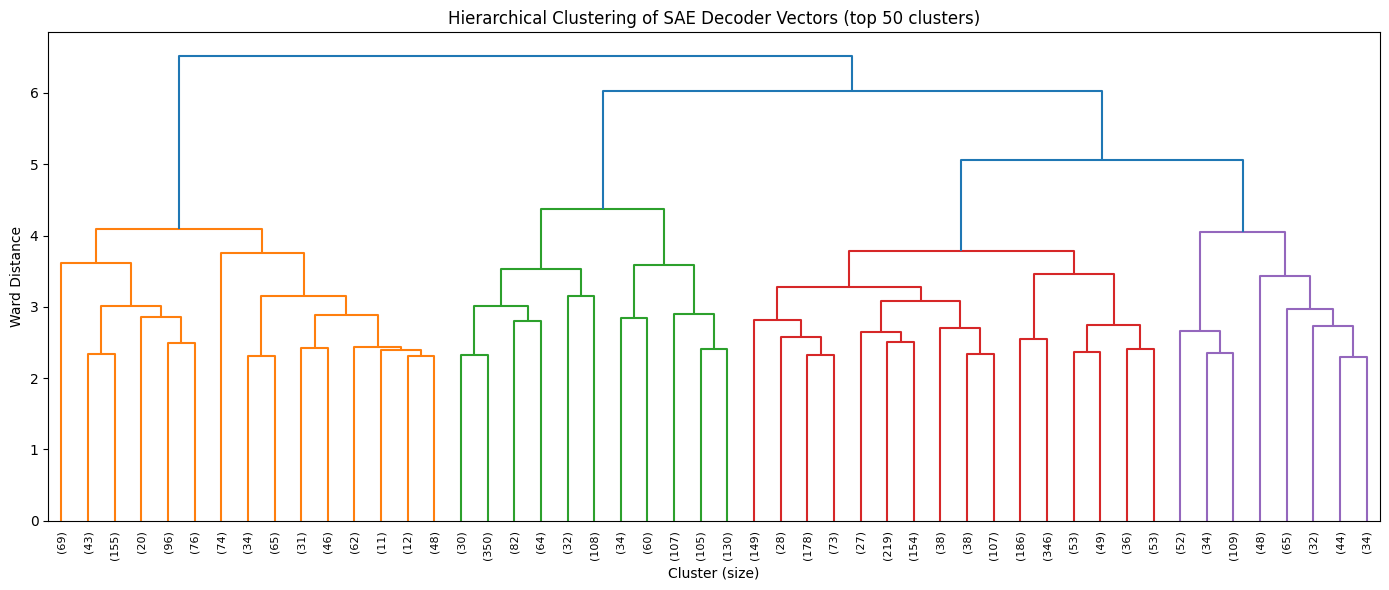

In [33]:
# Hierarchical clustering of decoder vectors + dendrogram
# Use cosine distance = 1 - cosine_similarity
cos_dist = 1 - cos_sim.numpy()
np.fill_diagonal(cos_dist, 0)
cos_dist = np.clip(cos_dist, 0, 2)  # ensure no negative distances from floating point

condensed_dist = squareform(cos_dist)
Z = linkage(condensed_dist, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=50, leaf_rotation=90, leaf_font_size=8,
           show_leaf_counts=True)
plt.title("Hierarchical Clustering of SAE Decoder Vectors (top 50 clusters)")
plt.xlabel("Cluster (size)")
plt.ylabel("Ward Distance")
plt.tight_layout()
plt.show()

In [35]:
def search_token(query, k=5):
    """Find features whose top-K activating tokens match the query.
    
    Matches any token containing the query string (case-insensitive).
    """
    results = []
    for feat_idx in range(m):
        idxs = top_idxs[feat_idx]
        valid = idxs[idxs >= 0]
        for rank, tok_idx in enumerate(valid[:K]):
            tok = all_tokens[tok_idx.item()]
            if query.lower() in tok.lower():
                results.append((feat_idx, rank, top_vals[feat_idx, rank].item(), tok))
                break  # only count best rank per feature

    results.sort(key=lambda x: x[1])  # sort by rank (0 = top token)
    print(f"Features with '{query}' in top-{K} tokens: {len(results)}\n")
    for feat_idx, rank, val, tok in results[:20]:
        print(f"  Feature {feat_idx}: rank={rank}, activation={val:.3f}, token={repr(tok)}")
    return results

# Example usage:
search_token(" governor")
print()

Features with ' governor' in top-20 tokens: 1

  Feature 1218: rank=2, activation=3.024, token=' Governor'



In [36]:
# inspect_feature(1896, k=10)
inspect_feature(1218, k=10)

Feature 1218 — top 10 activating tokens:

  3.089  token=    ' Attorney'   context: BROWNSVILLE, Texas -- A county employee is accused of intercepting deliveries of
  3.039  token=      'General'   context: OTTAWA — Last October, the House of Commons agreed to send “military assets,” in
  3.024  token=    ' Governor'   context: Sharing the user name and password of any streaming media account is now conside
  3.011  token=    ' Attorney'   context: Holdup manhunt takes 40 minutes

BEND, Ore. - A 28-year-old Bend man accused of 
  2.991  token=    ' Governor'   context: Texas Lt. Gov. Dan Patrick (REUTERS/Mike Stone/File Photo)

The Texas lieutenant
  2.955  token=            '.'   context: The so-called “Christmas Tree tax” had all the makings of a grand political thea
  2.943  token=    ' Attorney'   context: Update: Baroni, Kelly guilty on all counts

NEWARK--Defense attorneys Thursday a
  2.934  token=      'General'   context: Leaders of NATO and the European Union nations have sig

In [34]:
n_active = (top_vals[1896] > 0).sum().item()
print(f"Feature 1896: top activation = {top_vals[1896, 0]:.4f} ({n_active}/{K} top slots active)")

Feature 1896: top activation = 3.0767 (20/20 top slots active)
